In [ ]:
!pip install groq networkx scikit-learn matplotlib seaborn -q
print("✅ Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 5.4 MB/s eta 0:00:00
✅ Done!


In [ ]:
from groq import Groq

GROQ_API_KEY = "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"
client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client ready!")

✅ Groq client ready!


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# NetworkX has this dataset built-in — no download needed!
G = nx.karate_club_graph()

# Ground truth communities (from the graph metadata)
# Karate club has 2 factions: "Mr. Hi" and "Officer"
ground_truth = {}
for node in G.nodes():
    club = G.nodes[node]['club']
    ground_truth[node] = 0 if club == 'Mr. Hi' else 1

print(f"✅ Graph loaded!")
print(f"   Nodes : {G.number_of_nodes()}")
print(f"   Edges : {G.number_of_edges()}")
print(f"   Communities (ground truth): 2")
print(f"\nGround truth labels: {ground_truth}")

✅ Graph loaded!
   Nodes : 34
   Edges : 78
   Communities (ground truth): 2

Ground truth labels: {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 1, 10: 0, 11: 0, 12: 0, 13: 0, 14: 1, 15: 1, 16: 0, 17: 0, 18: 1, 19: 0, 20: 1, 21: 0, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1}


Graph to Text Conversion (Step 1 of CommLLM)

In [ ]:
def graph_to_text(G):
    """
    Converts a NetworkX graph into a plain-English
    adjacency description, exactly as done in the paper.
    """
    lines = []
    for node in sorted(G.nodes()):
        neighbors = sorted(list(G.neighbors(node)))
        neighbor_str = ", ".join(map(str, neighbors))
        lines.append(f"Node {node} is connected to: {neighbor_str}")

    return "\n".join(lines)

graph_text = graph_to_text(G)

print("📄 Graph-to-Text Conversion (first 5 lines):")
print("-" * 50)
for line in graph_text.split('\n')[:5]:
    print(line)
print("...")
print(f"\nTotal characters in prompt input: {len(graph_text)}")

📄 Graph-to-Text Conversion (first 5 lines):
--------------------------------------------------
Node 0 is connected to: 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31
Node 1 is connected to: 0, 2, 3, 7, 13, 17, 19, 21, 30
Node 2 is connected to: 0, 1, 3, 7, 8, 9, 13, 27, 28, 32
Node 3 is connected to: 0, 1, 2, 7, 12, 13
Node 4 is connected to: 0, 6, 10
...

Total characters in prompt input: 1366


The CommLLM Prompt (Step 2 of CommLLM)

In [ ]:
def build_prompt(graph_text):
    """
    Builds the exact prompt used in the paper (Prompt 4 / CommLLM prompt).
    """
    prompt = f"""{graph_text}

A community is a group of nodes that are more densely connected to each other internally than to the rest of the network. You are doing community detection. Based on these node connections, which community each node belongs? Give outcome as Node:<node id>; Community:<Community id> format. Do not give any other text."""

    return prompt

prompt = build_prompt(graph_text)

print("📋 Final Prompt (last part shown):")
print("-" * 50)
print("..." + prompt[-300:])
print(f"\nTotal prompt length: {len(prompt)} characters")

📋 Final Prompt (last part shown):
--------------------------------------------------
...group of nodes that are more densely connected to each other internally than to the rest of the network. You are doing community detection. Based on these node connections, which community each node belongs? Give outcome as Node:<node id>; Community:<Community id> format. Do not give any other text.

Total prompt length: 1685 characters


 Run CommLLM (Query Gemini)

In [ ]:
import time
import re

def run_commllm(prompt, runs=3):
    """
    Calls LLaMA3-70B via Groq with the CommLLM prompt.
    Runs multiple times to handle hallucinations.
    """
    responses = []

    print(f"🔄 Running CommLLM {runs} times to average out hallucinations...\n")

    for i in range(runs):
        print(f"  Run {i+1}/{runs}...", end=" ")
        try:
            chat_completion = client.chat.completions.create(
                messages=[
                    {
                        "role": "user",
                        "content": prompt
                    }
                ],
                model="llama-3.3-70b-versatile",  # same model family as paper baseline
                temperature=0.2,   # low temp = more consistent outputs
                max_tokens=2048,
            )
            response_text = chat_completion.choices[0].message.content
            responses.append(response_text)
            print("✅")
        except Exception as e:
            print(f"❌ Error: {e}")
            responses.append(None)
        time.sleep(2)

    return responses

responses = run_commllm(prompt, runs=3)

print("\n📤 Sample raw output from Run 1:")
print("-" * 50)
print(responses[0][:500] if responses[0] else "No response")

🔄 Running CommLLM 3 times to average out hallucinations...

  Run 1/3... ✅
  Run 2/3... ✅
  Run 3/3... ✅

📤 Sample raw output from Run 1:
--------------------------------------------------
Node:0; Community:1
Node:1; Community:1
Node:2; Community:1
Node:3; Community:1
Node:4; Community:2
Node:5; Community:2
Node:6; Community:2
Node:7; Community:1
Node:8; Community:1
Node:9; Community:3
Node:10; Community:2
Node:11; Community:1
Node:12; Community:1
Node:13; Community:1
Node:14; Community:3
Node:15; Community:3
Node:16; Community:2
Node:17; Community:1
Node:18; Community:3
Node:19; Community:1
Node:20; Community:3
Node:21; Community:1
Node:22; Community:3
Node:23; Community:3
Node:2


Parse LLM Output into Community Labels

In [ ]:
def parse_response(response_text, num_nodes=34):
    """
    Parses the LLM's output into a dict: {node_id: community_id}
    Handles slight formatting variations in output.
    """
    if response_text is None:
        return None

    community_map = {}

    # Regex to match "Node:X; Community:Y" or "Node: X; Community: Y"
    pattern = r'Node\s*:\s*(\d+)\s*;\s*Community\s*:\s*(\d+)'
    matches = re.findall(pattern, response_text)

    for node_str, comm_str in matches:
        node_id = int(node_str)
        comm_id = int(comm_str)
        if 0 <= node_id < num_nodes:
            community_map[node_id] = comm_id

    return community_map if len(community_map) > 0 else None


# Parse all runs
parsed_results = []
for i, resp in enumerate(responses):
    parsed = parse_response(resp)
    if parsed:
        parsed_results.append(parsed)
        print(f"Run {i+1}: Parsed {len(parsed)} node assignments ✅")
    else:
        print(f"Run {i+1}: Parse failed ❌")

print(f"\n✅ Successfully parsed {len(parsed_results)} / {len(responses)} runs")

Run 1: Parsed 34 node assignments ✅
Run 2: Parsed 34 node assignments ✅
Run 3: Parsed 34 node assignments ✅

✅ Successfully parsed 3 / 3 runs


Average Predictions Across Runs

In [ ]:
from collections import Counter

def average_predictions(parsed_results, num_nodes=34):
    """
    For each node, takes the majority-voted community across all runs.
    This is how the paper handles LLM variance.
    """
    final_assignment = {}

    for node in range(num_nodes):
        votes = []
        for result in parsed_results:
            if node in result:
                votes.append(result[node])

        if votes:
            # majority vote
            final_assignment[node] = Counter(votes).most_common(1)[0][0]
        else:
            final_assignment[node] = -1  # unassigned

    return final_assignment

final_communities = average_predictions(parsed_results)

print("🗳️ Final community assignments (majority vote):")
print("-" * 50)
for node, comm in sorted(final_communities.items()):
    print(f"  Node {node:2d} → Community {comm}")

🗳️ Final community assignments (majority vote):
--------------------------------------------------
  Node  0 → Community 1
  Node  1 → Community 1
  Node  2 → Community 1
  Node  3 → Community 1
  Node  4 → Community 2
  Node  5 → Community 2
  Node  6 → Community 2
  Node  7 → Community 1
  Node  8 → Community 1
  Node  9 → Community 3
  Node 10 → Community 2
  Node 11 → Community 1
  Node 12 → Community 1
  Node 13 → Community 1
  Node 14 → Community 3
  Node 15 → Community 3
  Node 16 → Community 2
  Node 17 → Community 1
  Node 18 → Community 3
  Node 19 → Community 1
  Node 20 → Community 3
  Node 21 → Community 1
  Node 22 → Community 3
  Node 23 → Community 3
  Node 24 → Community 4
  Node 25 → Community 4
  Node 26 → Community 3
  Node 27 → Community 3
  Node 28 → Community 3
  Node 29 → Community 3
  Node 30 → Community 3
  Node 31 → Community 4
  Node 32 → Community 3
  Node 33 → Community 3


In [ ]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.metrics.cluster import contingency_matrix

def compute_purity(true_labels, pred_labels):
    cm = contingency_matrix(true_labels, pred_labels)
    return np.sum(np.amax(cm, axis=0)) / np.sum(cm)

def compute_voi(true_labels, pred_labels):
    """Variation of Information"""
    n = len(true_labels)

    # Joint and marginal entropies
    cm = contingency_matrix(true_labels, pred_labels)
    cm_norm = cm / n

    # Marginals
    p_true = cm_norm.sum(axis=1)
    p_pred = cm_norm.sum(axis=0)

    # Entropies
    H_true = -np.sum(p_true[p_true > 0] * np.log2(p_true[p_true > 0]))
    H_pred = -np.sum(p_pred[p_pred > 0] * np.log2(p_pred[p_pred > 0]))

    # Mutual information
    mi = normalized_mutual_info_score(true_labels, pred_labels) * (H_true + H_pred) / 2

    voi = H_true + H_pred - 2 * mi
    return max(0, voi)

# Prepare label arrays
true_labels = [ground_truth[i] for i in range(34)]
pred_labels = [final_communities[i] for i in range(34)]

# Compute metrics
nmi   = normalized_mutual_info_score(true_labels, pred_labels)
ari   = adjusted_rand_score(true_labels, pred_labels)
purity = compute_purity(true_labels, pred_labels)
voi   = compute_voi(true_labels, pred_labels)

print("=" * 50)
print("📊 EVALUATION RESULTS (CommLLM on Karate Club)")
print("=" * 50)
print(f"  NMI    (↑ higher better) : {nmi:.4f}")
print(f"  ARI    (↑ higher better) : {ari:.4f}")
print(f"  Purity (↑ higher better) : {purity:.4f}")
print(f"  VOI    (↓ lower better)  : {voi:.4f}")
print("=" * 50)
print("\n📄 Paper's reported CommLLM scores:")
print("  NMI = 0.90 | ARI = 0.93 | Purity = 0.98 | VOI = 0.11")

📊 EVALUATION RESULTS (CommLLM on Karate Club)
  NMI    (↑ higher better) : 0.7212
  ARI    (↑ higher better) : 0.6320
  Purity (↑ higher better) : 1.0000
  VOI    (↓ lower better)  : 0.7731

📄 Paper's reported CommLLM scores:
  NMI = 0.90 | ARI = 0.93 | Purity = 0.98 | VOI = 0.11


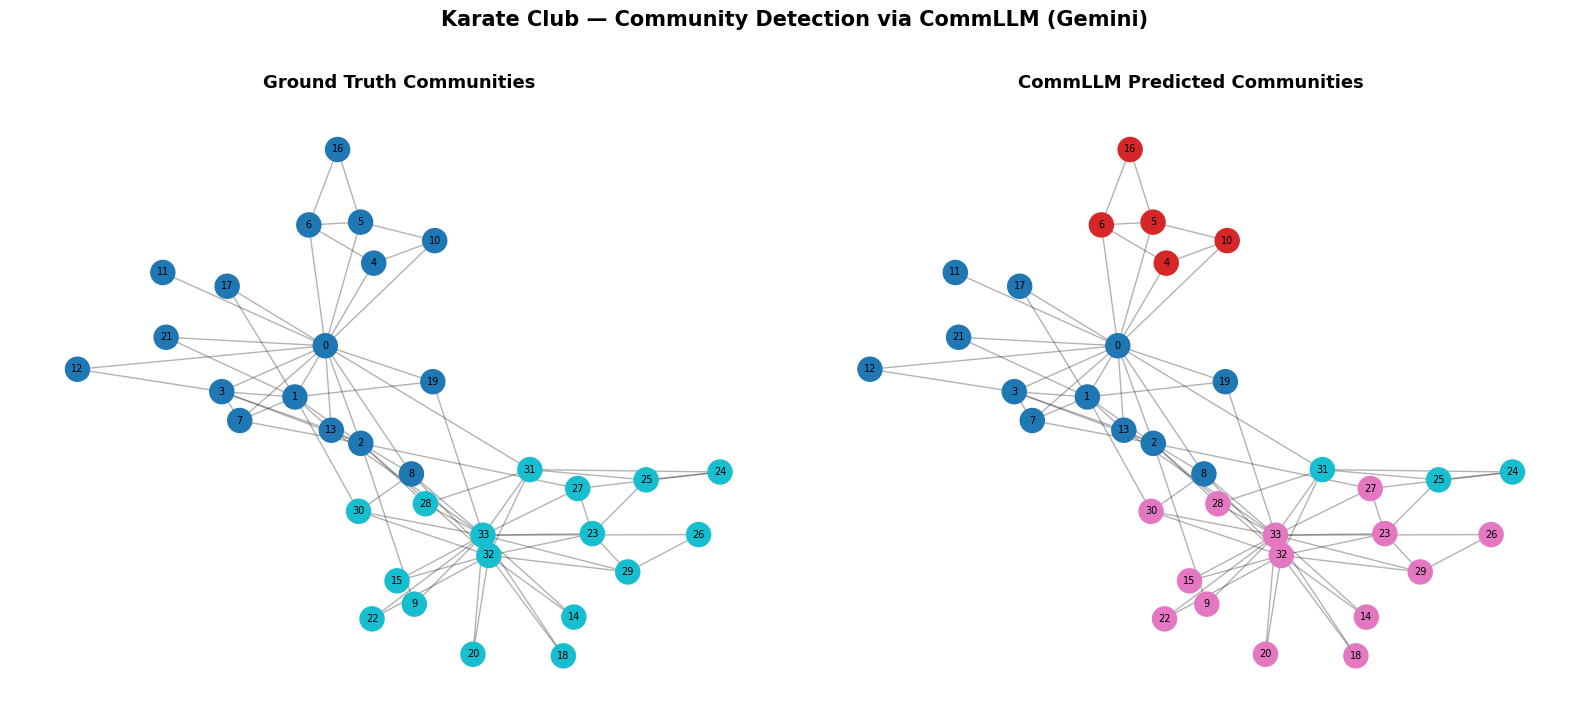

✅ Plot saved as commllm_result.png


In [ ]:
def plot_communities(G, label_dict, title, ax):
    pos = nx.spring_layout(G, seed=42)
    communities = list(set(label_dict.values()))
    colors = cm.tab10(np.linspace(0, 1, len(communities)))
    color_map = {c: colors[i] for i, c in enumerate(communities)}

    node_colors = [color_map[label_dict[n]] for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                           node_size=300, ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_communities(G, ground_truth,     "Ground Truth Communities",       axes[0])
plot_communities(G, final_communities, "CommLLM Predicted Communities", axes[1])

plt.suptitle("Karate Club — Community Detection via CommLLM (Gemini)",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("commllm_result.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plot saved as commllm_result.png")